In [9]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp
import time
from scipy import special as scisp
from scipy.integrate import solve_ivp
from scipy.interpolate import InterpolatedUnivariateSpline,CubicSpline
import scipy.integrate
import scipy.optimize
import multiprocessing
from tqdm import trange
from scipy.optimize import curve_fit
import matplotlib.cm as cm
from matplotlib.gridspec import GridSpec
from scipy.interpolate import interp1d
from matplotlib.ticker import LogLocator, NullFormatter
import sys
from pathlib import Path
# add main_directory/ to the import path
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))
from source.SecludedDM import Cosmology, HiggsPortal, BoltzmannSolver, find_mXstar

plt.style.use('/home/gab/Desktop/PyCharm_env/mine.mplstyle')
plt.rcParams["axes.axisbelow"] = False
cosmo = Cosmology(gstar_choice="standard", gstarpath="./notebooks/")

In [2]:
lam = .25
r = 20.0
mX = 1e2
mY = mX / r
cosmo = Cosmology(gstar_choice="standard", gstarpath="./notebooks/")
model = HiggsPortal(mX=mX, mY=mY, lam=lam)
solver = BoltzmannSolver(cosmo, model)

In [3]:
sol = solver.solve_boltzmann_chempot_QSSA(return_bg_ICs=True, verbose=True,cannibal_switch_full=1)
print(f"\nYX_relic = {sol['YX_relic']:.4e}")

Boltzmann Solver -- QSSA Three-Phase
  mX = 1.00e+02 GeV, mY = 5.00e+00 GeV, r = 20.00
  Phase 1->1.5: Gamma_ann < 5e+09
  Phase 1.5->2: Gamma_can < 1e+00
  Convergence: dlnxi_NR, thr=0.01
------------------------------------------------------------


Evolving:  22%|█████████████████████                                                                            | 26/120 [00:01<00:02, 38.05it/s]


  -> Phase 1.5 (QSSA) at x = 12.49 (Gamma_ann = 3.5e+09)


Evolving:  96%|██████████████████████████████████████████████████████▋  | 115/120 [00:04<00:00, 43.69it/s, ph=1.5, x=999, muX=150.0, dev=1.9e+00]


  -> Phase 2 (full) at x = 999.00 (Gamma_can=1.6e-01, muX=150.03)


Evolving:  98%|███████████████████████████████████████████████████████ | 118/120 [00:14<00:00,  7.90it/s, ph=2, x=9990, muX=14327.5, dev=9.3e-03]



  Converged (2, dlnxi_NR) at x = 9990.0
------------------------------------------------------------
RESULTS:
  x_switch (eq -> QSSA): 12.49
  x_switch (QSSA -> full): 999.00
  x_FO (muX > 0.05): 42.3
  Converged: True at x = 9990.0
  YX_relic = 2.802197e-13

YX_relic = 2.8022e-13


In [20]:
model1 = HiggsPortal(mX=mX, mY=mY, lam=lam,Delta1=0)
solver1 = BoltzmannSolver(cosmo, model1)
sol1= solver1.solve_boltzmann_chempot_QSSA(return_bg_ICs=True, verbose=True,cannibal_switch_full=5,Gamma_switch_full=1e4)

Boltzmann Solver -- QSSA Three-Phase
  mX = 1.00e+04 GeV, mY = 5.00e+02 GeV, r = 20.00
  Phase 1->1.5: Gamma_ann < 5e+09
  Phase 1.5->2: Gamma_ann < 1e+04 AND Gamma_can < 5e+00
  Convergence: dlnxi_NR, thr=0.01
------------------------------------------------------------


Evolving:   2%|█▋                                                                                                | 2/120 [00:00<00:07, 16.17it/s]


  -> Phase 1.5 (QSSA) at x = 0.10 (Gamma_ann = 4.5e+09)


Evolving:  28%|██████████████████████████▋                                                                      | 33/120 [00:01<00:03, 24.21it/s]


  -> Phase 2 (full) at x = 18.48 (Gamma_ann=6.8e+04, Gamma_can=3.5e+00, muX=0.00)


Evolving:  97%|██████████████████████████████████████████████████████▏ | 116/120 [00:04<00:00, 24.77it/s, ph=2, x=1998, muX=19647.8, dev=5.1e-03]



  Converged (2, dlnxi_NR) at x = 1998.0
------------------------------------------------------------
RESULTS:
  x_switch (eq -> QSSA): 0.10
  x_switch (QSSA -> full): 18.48
  x_FO (muX > 0.05): 24.1
  Converged: True at x = 1998.0
  YX_relic = 6.685333e-10


In [22]:
model2 = HiggsPortal(mX=mX, mY=mY, lam=lam,Delta3=0)
solver2 = BoltzmannSolver(cosmo, model2)
sol2= solver2.solve_boltzmann_chempot_QSSA(return_bg_ICs=True, verbose=True,cannibal_switch_full=.01,Gamma_switch_full=1e4)

Boltzmann Solver -- QSSA Three-Phase
  mX = 1.00e+04 GeV, mY = 5.00e+02 GeV, r = 20.00
  Phase 1->1.5: Gamma_ann < 5e+09
  Phase 1.5->2: Gamma_ann < 1e+04 AND Gamma_can < 1e-02
  Convergence: dlnxi_NR, thr=0.01
------------------------------------------------------------


Evolving:   2%|█▋                                                                                                | 2/120 [00:00<00:07, 16.17it/s]


  -> Phase 1.5 (QSSA) at x = 0.10 (Gamma_ann = 4.5e+09)


Evolving:  28%|███████████████████████████▍                                                                     | 34/120 [00:01<00:02, 28.81it/s]


  -> Phase 2 (full) at x = 22.48 (Gamma_ann=8.1e+03, Gamma_can=9.7e+01, muX=0.00)


Evolving:  97%|██████████████████████████████████████████████████████▏ | 116/120 [00:04<00:00, 23.64it/s, ph=2, x=1998, muX=10987.4, dev=9.3e-03]



  Converged (2, dlnxi_NR) at x = 1998.0
------------------------------------------------------------
RESULTS:
  x_switch (eq -> QSSA): 0.10
  x_switch (QSSA -> full): 22.48
  x_FO (muX > 0.05): 30.0
  Converged: True at x = 1998.0
  YX_relic = 7.011927e-10


No handles with labels found to put in legend.


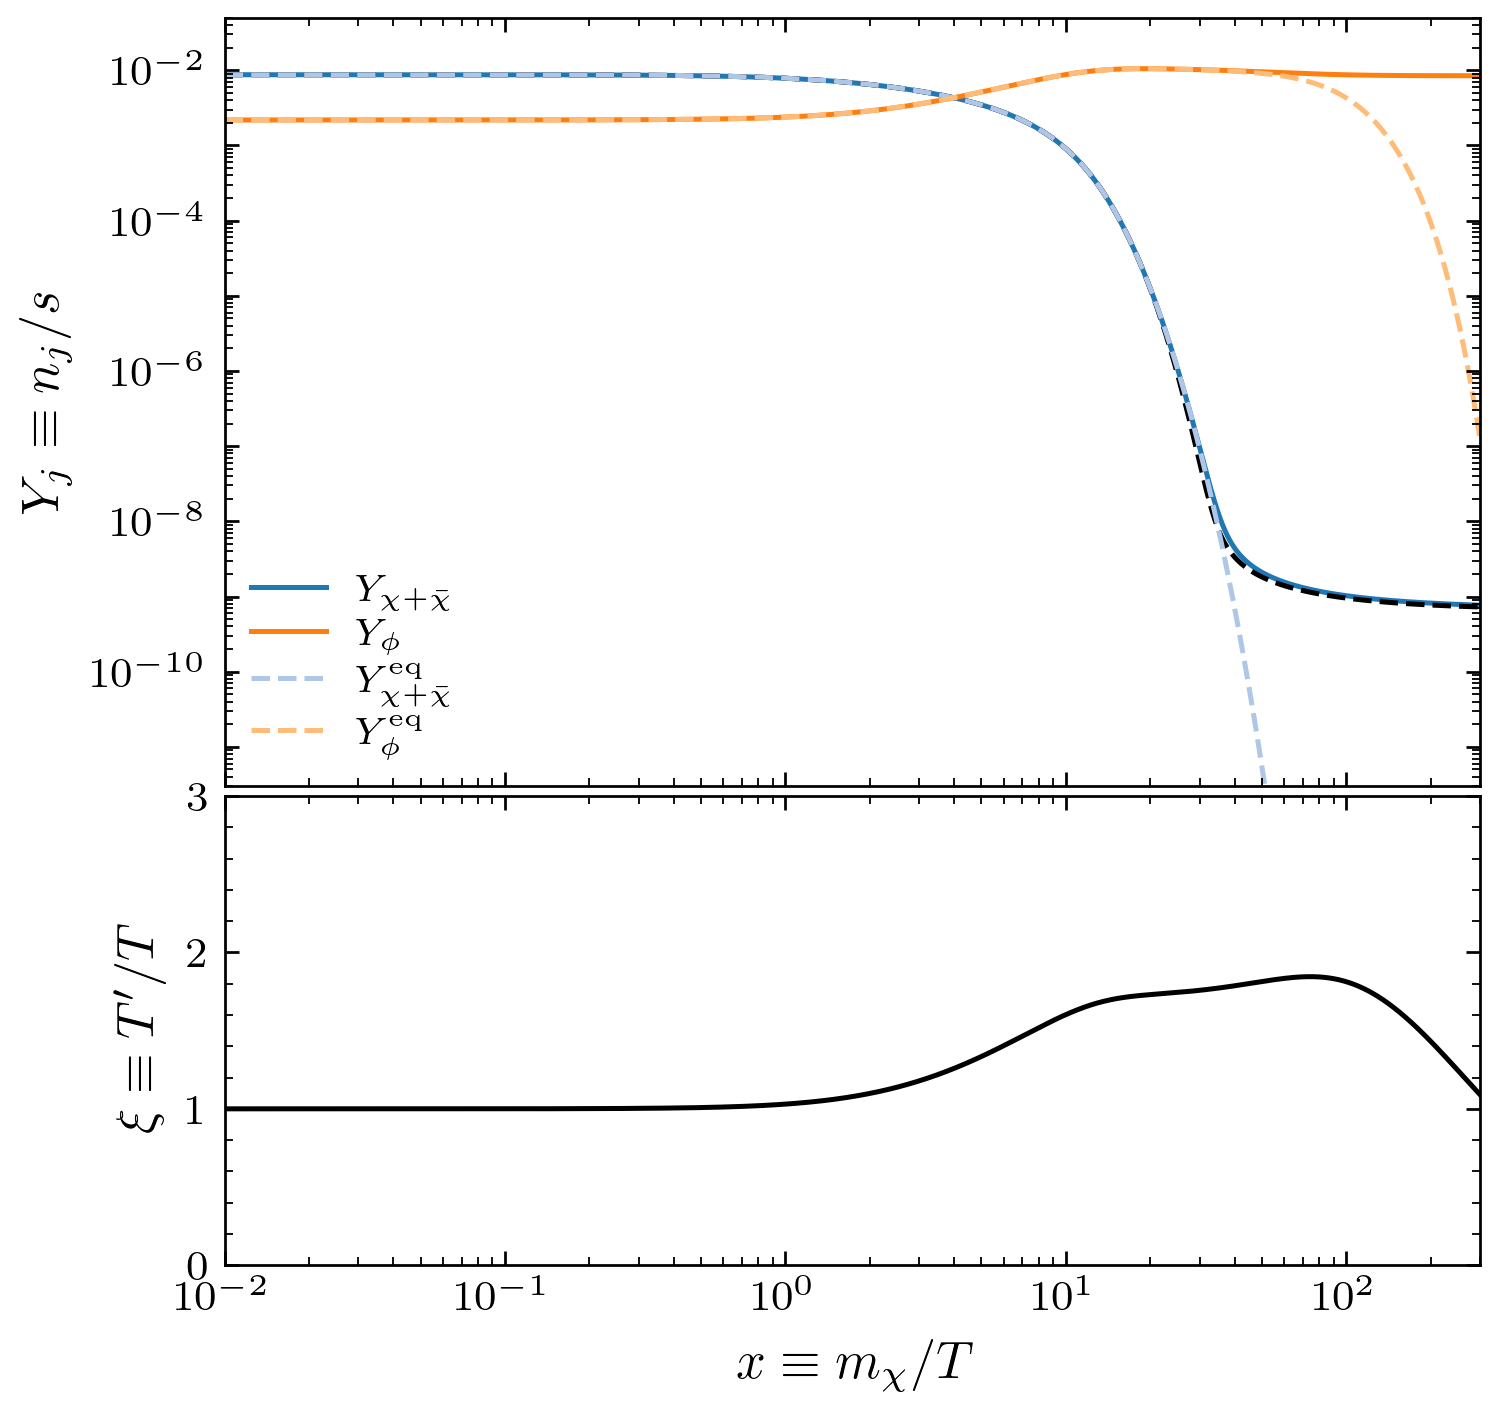

In [24]:
cs=plt.cm.tab20([0,1,2,3,4,5,6,7,8])
fig1=plt.figure(figsize=(4.5, 4.5))
gs1 = GridSpec(21,23,figure=fig1)
ax1 = fig1.add_subplot(gs1[:13,:])
ax2 = fig1.add_subplot(gs1[13:,:])
ax1.plot(sol['x'],sol['YX'],lw=1,c=cs[0],label=r'$Y_{\chi+\bar\chi}$')
ax1.plot(sol1['x'],sol1['YX'],lw=1,c='k', ls='--')
ax1.plot(sol['x'],sol['YY'],lw=1,c=cs[2],label=r'$Y_{\phi}$')
ax1.plot(sol['x'],sol['YXeq'],lw=1,c=cs[1],ls='--',label=r'$Y^{\rm eq}_{\chi+\bar\chi}$')
ax1.plot(sol['x'],sol['YYeq'],lw=1,c=cs[3],ls='--',label=r'$Y^{\rm eq}_{\phi}$')
ax1.legend()
ax2.plot(sol['x'],sol['xi'],lw=1,c='k')
#ax2.plot(sol['x'],xi_lim,lw=1,c='tab:red',ls='--',label=r'$\frac{d\ln \xi}{d\ln x}= -\frac{1}{3}\frac{d\ln{g}_S}{d\ln T}$')
ax2.legend()
#ax2.axvline(sol['x_switch'],lw=1,ls='--',c='tab:gray',zorder=-1)
ax1.set_xscale("log")
ax2.set_xscale("log")
ax1.set_yscale("log")
ax1.set_ylabel(r"$Y_{j}\equiv n_j/s$")
ax2.set_ylabel(r"$\xi\equiv T^\prime/T$")
ax2.set_xlabel(r"$x\equiv m_\chi/T$")
ax1.set_ylim(3e-12,5e-2)
ax1.set_xlim(1e-2,3e2)
ax2.set_xlim(1e-2,3e2)
ax1.set_xticklabels([])
ax2.set_ylim(0.,3)
ax1.set_yticks([1e-11,1e-10,1e-9,1e-8,1e-7,1e-6,1e-5,1e-4,1e-3,1e-2])
ax1.set_yticklabels(['',r'$10^{-10}$','',r'$10^{-8}$','',r'$10^{-6}$','',r'$10^{-4}$','',r'$10^{-2}$'])
ax1.yaxis.set_minor_locator(LogLocator(base=10.0, subs=[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,.9], numticks=2000))
ax1.yaxis.set_minor_formatter(NullFormatter())
plt.show()
plt.close()

In [3]:
lam = .05
r = 1.5
cosmo = Cosmology(gstar_choice="standard", gstarpath="./notebooks/")
factory = lambda mX, mY: HiggsPortal(mX=mX, mY=mY, lam=lam)
res = find_mXstar(cosmo, factory, r=r, verbose=True,verbose_solver=True)
print(f"\nmXstar = {res['mXstar']:.4e} GeV")
print(f"epsX_min = {res['epsX_min']:.4e}")

find_mXstar  (r=1.50)
  mX_est = 5.11e+01 GeV  bracket = [5.11e+00, 2.55e+02]
------------------------------------------------------------
Boltzmann Solver -- QSSA Three-Phase
  mX = 5.11e+00 GeV, mY = 3.41e+00 GeV, r = 1.50
  Phase 1->1.5: Gamma_ann < 5e+09
  Phase 1.5->2: Gamma_can < 1e+00
  Convergence: dlnxi_NR, thr=0.01
------------------------------------------------------------


Evolving:  16%|███████████████                                                                                  | 20/129 [00:01<00:04, 23.09it/s]


  -> Phase 1.5 (QSSA) at x = 5.26 (Gamma_ann = 4.4e+09)


Evolving:  31%|██████████████████████████████                                                                   | 40/129 [00:02<00:02, 38.03it/s]


  -> Phase 2 (full) at x = 27.47 (Gamma_can=9.1e-01, muX=0.00)


...


  -> Phase 1.5 (QSSA) at x = 2.89 (Gamma_ann = 4.6e+09)


Evolving:  29%|███████████████████████████▊                                                                     | 37/129 [00:02<00:02, 38.87it/s]


  -> Phase 2 (full) at x = 28.47 (Gamma_can=9.1e-01, muX=0.00)


Evolving:  88%|███████████████████████████████████████████████████▎      | 114/129 [02:04<00:16,  1.09s/it, ph=2, x=500, muX=2287.7, dev=3.5e-03]



  Converged (2, dlnxi_NR) at x = 499.5
------------------------------------------------------------
RESULTS:
  x_switch (eq -> QSSA): 2.89
  x_switch (QSSA -> full): 28.47
  x_FO (muX > 0.05): 28.8
  Converged: True at x = 499.5
  YX_relic = 8.580889e-11
  => epsX_min = 7.5082e-08  (dS/S < 0.001)  SRatio_plateau = 2.2688

mXstar = 1.1565e+01 GeV
epsX_min = 7.5082e-08


In [14]:
mXs=np.linspace(res['mXstar']*(1+1e-1),10*res['mXstar'],50)
mYs=mXs/r
epsXs=np.zeros(len(mXs))
epsXs_bbn=np.zeros(len(mXs))
t_start=time.time()
for i in trange(len(mXs)):
    model = HiggsPortal(
        mX=mXs[i],       
        mY=mYs[i],       
        lam=lam,
    )
    solver = BoltzmannSolver(cosmo, model)
    sol0 = solver.solve_boltzmann_chempot_QSSA(return_bg_ICs=True, verbose=False, cannibal_switch_full=1,
                                                 convergence_threshold=2e-2)
    epsXs[i]= solver.find_epsilon_DMRelic(sol0['bg_ICs'],log10eps_range=(-18,-8),root_rtol= 1e-4)
    #print(epsXs[i],mXs[i])
    epsXs_bbn[i]=solver.find_epsilon_BBN_Neff(sol0['bg_ICs'],T_eval=1e-3,log10eps_range=(-15,-9),root_rtol=1e-3)
    #print(epsXs[i],epsXs_bbn[i])
    #print("t=",time.time()-t_start)
    #break
    del model, solver
data = np.column_stack([mXs, mYs, epsXs, epsXs_bbn])
header = (f"lam_s=lam_p={lam:.1e}  r={r}  mXstar={res['mXstar']:.6e}  "
          f"epsX_min={res['epsX_min']:.6e}  SRatio_plateau={res['SRatio_plateau']:.4f}\n"
          f"mX [GeV]    mY [GeV]    epsX_relic    epsX_bbn_Neff")
np.savetxt(f"../output/hP/relic_lam{lam:.0e}_r{r}.dat", data, header=header, fmt='%.8e')

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [44:13<00:00, 53.06s/it]


In [19]:
def load_relic(fname):
    with open(fname) as f:
        params = dict(s.split('=') for s in f.readline().lstrip('# ').split())
    mXs, mYs, epsXs, epsXs_bbn = np.loadtxt(fname).T
    return {**{k: float(v) for k, v in params.items()},
            'mXs': mXs, 'mYs': mYs, 'epsXs': epsXs, 'epsXs_bbn': epsXs_bbn}
    
dat1 = load_relic("../output/hP/relic_lam5e-02_r1.5.dat")
mXs1, mYs1, epsXs1, epsXs_bbn1 = dat1['mXs'],dat1['mYs'],dat1['epsXs'],dat1['epsXs_bbn']
mXs1  = np.concatenate([[dat1['mXstar'], dat1['mXstar']*(1+1e-6)], mXs1])
epsXs1 = np.concatenate([[1e-4, dat1['epsX_min']],    epsXs1])

In [20]:
bbn_bound=interp1d(mXs1[2:],epsXs_bbn1, kind="linear", fill_value="extrapolate", bounds_error=False)
mXs_bbn=np.concatenate([[0.9*mXs1[0]],mXs1])

No handles with labels found to put in legend.


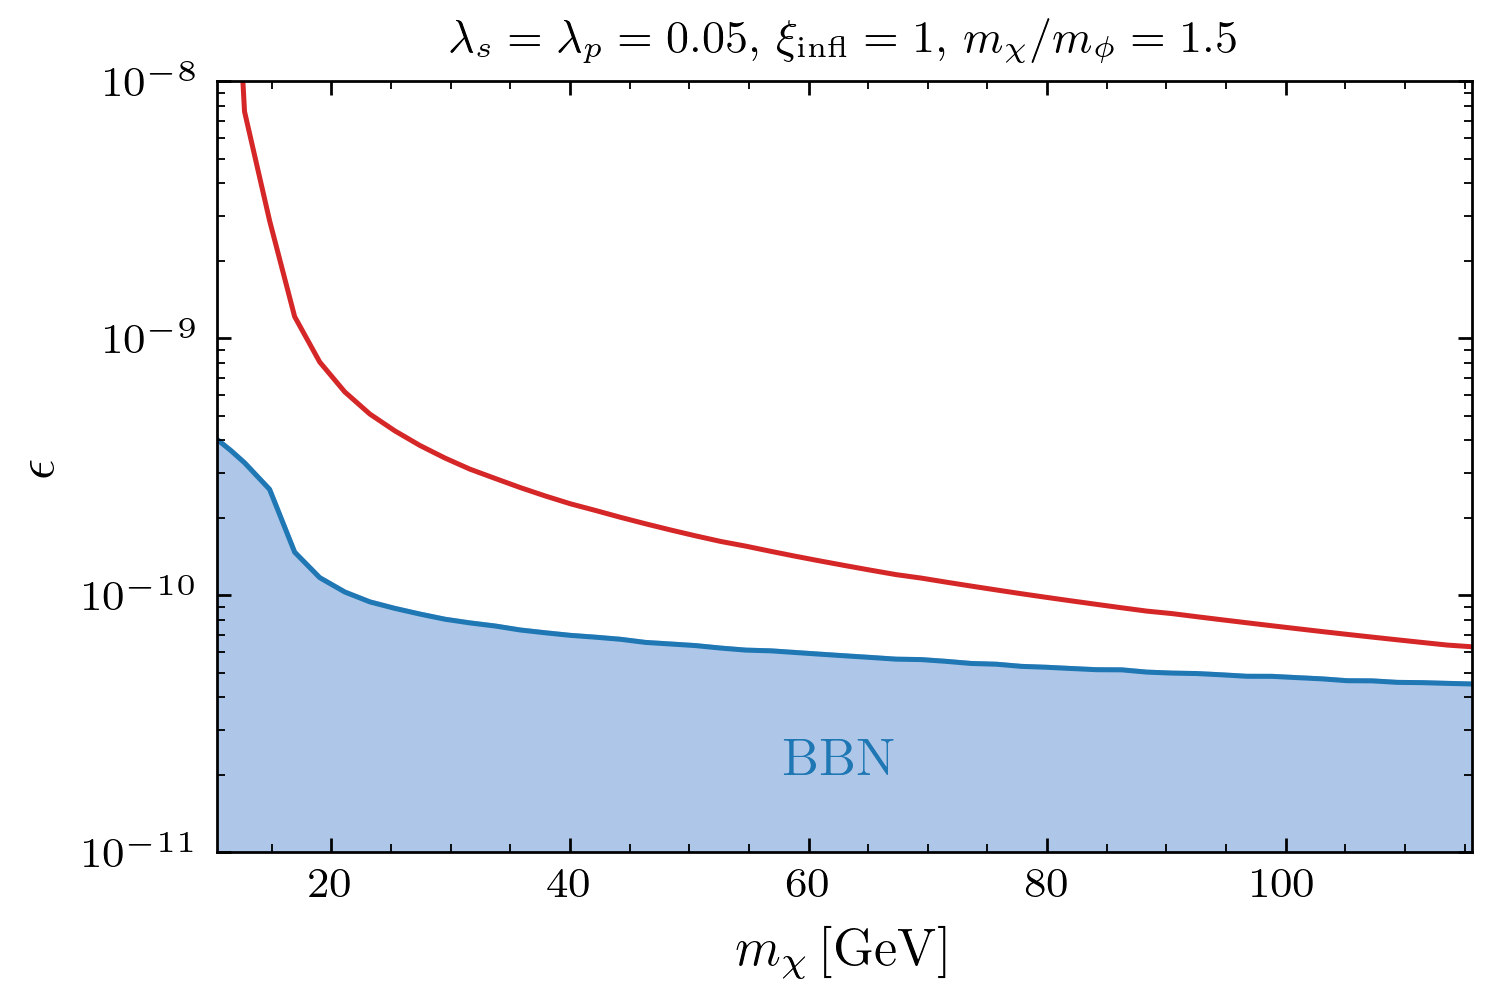

In [30]:
cs=plt.cm.tab20([0,1,2,3,4,5,6,7,8])
plt.plot(mXs1,epsXs1,lw=1,c=cs[6])
plt.fill_between(mXs_bbn,0, bbn_bound(mXs_bbn),lw=1,color=cs[1],alpha=1)
plt.plot(mXs_bbn,bbn_bound(mXs_bbn),lw=1,color=cs[0],ls='-')
plt.legend()
plt.yscale("log")
plt.ylabel("$\epsilon$")
plt.ylim(1e-11,1e-8)
plt.title(r'$\lambda_s=\lambda_p=0.05,\,\xi_{\rm infl}=1,\,m_\chi/m_{\phi}=1.5$',fontsize=9)
plt.xlim(np.min(mXs1*(1-1e-1)),np.max(mXs1))
plt.text(dat1['mXstar']*5,2e-11,r"BBN",color=cs[0])
plt.xlabel(r"$m_\chi\,[{\rm GeV}]$")
plt.savefig("../figs/hP_lam5e-2_xiInf1_r1.5.png")
plt.savefig("../figs/hP_lam5e-2_xiInf1_r1.5.pdf")
plt.show()
plt.close()

In [31]:
lam = .1
r = 3
cosmo = Cosmology(gstar_choice="standard", gstarpath="./notebooks/")
factory = lambda mX, mY: HiggsPortal(mX=mX, mY=mY, lam=lam)
res = find_mXstar(cosmo, factory, r=r, verbose=True,verbose_solver=True)
print(f"\nmXstar = {res['mXstar']:.4e} GeV")
print(f"epsX_min = {res['epsX_min']:.4e}")

find_mXstar  (r=3.00)
  mX_est = 1.89e+02 GeV  bracket = [1.89e+01, 9.46e+02]
------------------------------------------------------------
Boltzmann Solver -- QSSA Three-Phase
  mX = 1.89e+01 GeV, mY = 6.31e+00 GeV, r = 3.00
  Phase 1->1.5: Gamma_ann < 5e+09
  Phase 1.5->2: Gamma_can < 1e+00
  Convergence: dlnxi_NR, thr=0.01
------------------------------------------------------------


Evolving:  19%|██████████████████▊                                                                              | 25/129 [00:01<00:03, 27.16it/s]


  -> Phase 1.5 (QSSA) at x = 8.57 (Gamma_ann = 4.8e+09)


Evolving:  51%|█████████████████████████████████████████████████▋                                               | 66/129 [00:02<00:01, 37.77it/s]


  -> Phase 2 (full) at x = 48.45 (Gamma_can=9.7e-01, muX=0.00)


...


  -> Phase 1.5 (QSSA) at x = 4.78 (Gamma_ann = 4.8e+09)


Evolving:  44%|██████████████████████████████████████████▊                                                      | 57/129 [00:02<00:01, 36.34it/s]


  -> Phase 2 (full) at x = 41.46 (Gamma_can=9.0e-01, muX=0.00)


Evolving:  89%|███████████████████████████████████████████████████▋      | 115/129 [00:04<00:00, 24.26it/s, ph=2, x=999, muX=9084.5, dev=2.0e-03]



  Converged (2, dlnxi_NR) at x = 999.0
------------------------------------------------------------
RESULTS:
  x_switch (eq -> QSSA): 4.78
  x_switch (QSSA -> full): 41.46
  x_FO (muX > 0.05): 41.8
  Converged: True at x = 999.0
  YX_relic = 1.567096e-11
  => epsX_min = 5.7964e-08  (dS/S < 0.001)  SRatio_plateau = 2.4888

mXstar = 6.9515e+01 GeV
epsX_min = 5.7964e-08


In [33]:
mXs=np.linspace(res['mXstar']*(1+1e-1),5*res['mXstar'],50)
mYs=mXs/r
epsXs=np.zeros(len(mXs))
epsXs_bbn=np.zeros(len(mXs))
t_start=time.time()
for i in trange(len(mXs)):
    model = HiggsPortal(
        mX=mXs[i],       
        mY=mYs[i],       
        lam=lam,
    )
    solver = BoltzmannSolver(cosmo, model)
    sol0 = solver.solve_boltzmann_chempot_QSSA(return_bg_ICs=True, verbose=False, cannibal_switch_full=1,
                                                 convergence_threshold=1e-2)
    epsXs[i]= solver.find_epsilon_DMRelic(sol0['bg_ICs'],log10eps_range=(-18,-8),root_rtol= 1e-4)
    #print(epsXs[i],mXs[i])
    epsXs_bbn[i]=solver.find_epsilon_BBN_Neff(sol0['bg_ICs'],T_eval=1e-3,log10eps_range=(-15,-9),root_rtol=1e-3)
    #print(epsXs[i],epsXs_bbn[i])
    #print("t=",time.time()-t_start)
    #break
    del model, solver
data = np.column_stack([mXs, mYs, epsXs, epsXs_bbn])
header = (f"lam={lam:.1e}  r={r}  mXstar={res['mXstar']:.6e}  "
          f"epsX_min={res['epsX_min']:.6e}  SRatio_plateau={res['SRatio_plateau']:.4f}\n"
          f"mX [GeV]    mY [GeV]    epsX_relic    epsX_bbn_Neff")
np.savetxt(f"../output/hP/relic_lam{lam:.0e}_r{r}.dat", data, header=header, fmt='%.8e')

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [06:17<00:00,  7.54s/it]


In [43]:
dat1 = load_relic("../output/hP/relic_lam1e-01_r3.dat")
mXs1, mYs1, epsXs1, epsXs_bbn1 = dat1['mXs'],dat1['mYs'],dat1['epsXs'],dat1['epsXs_bbn']
mXs1  = np.concatenate([[dat1['mXstar'], dat1['mXstar']*(1+1e-6)], mXs1])
epsXs1 = np.concatenate([[1e-4, dat1['epsX_min']],    epsXs1])
bbn_bound=interp1d(mXs1[2:],epsXs_bbn1, kind="linear", fill_value="extrapolate", bounds_error=False)
mXs_bbn=np.concatenate([[0.9*mXs1[0]],mXs1])

No handles with labels found to put in legend.


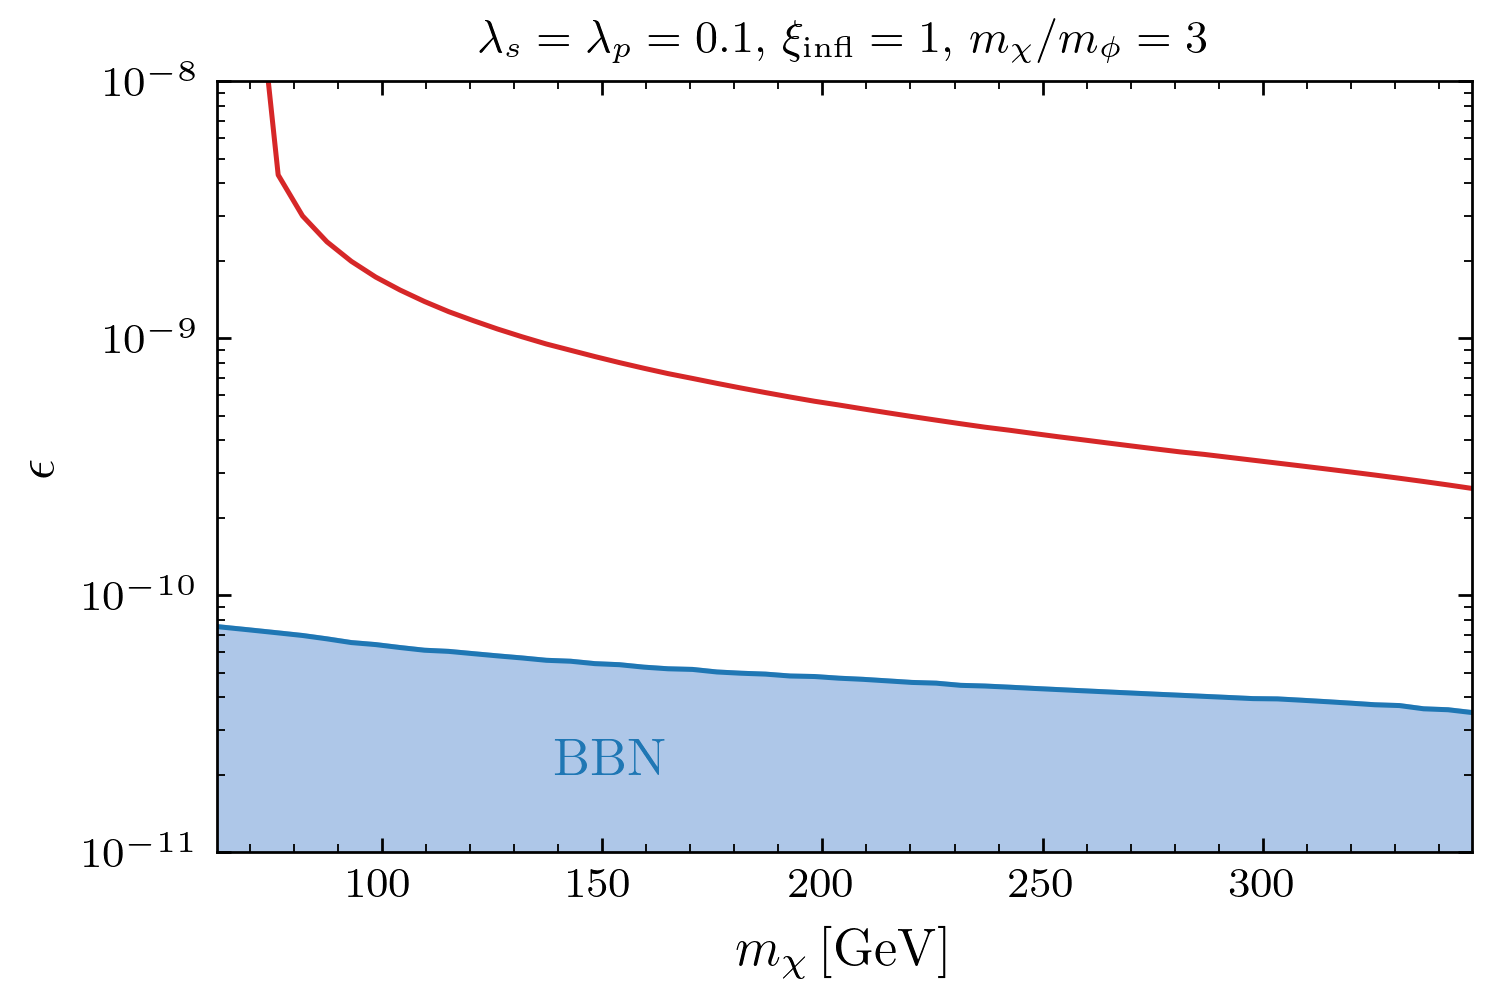

In [45]:
cs=plt.cm.tab20([0,1,2,3,4,5,6,7,8])
plt.plot(mXs1,epsXs1,lw=1,c=cs[6])
plt.fill_between(mXs_bbn,0, bbn_bound(mXs_bbn),lw=1,color=cs[1],alpha=1)
plt.plot(mXs_bbn,bbn_bound(mXs_bbn),lw=1,color=cs[0],ls='-')
plt.legend()
plt.yscale("log")
plt.ylabel("$\epsilon$")
plt.ylim(1e-11,1e-8)
plt.title(r'$\lambda_s=\lambda_p=0.1,\,\xi_{\rm infl}=1,\,m_\chi/m_{\phi}=3$',fontsize=9)
plt.xlim(np.min(mXs1*(1-1e-1)),np.max(mXs1))
plt.text(dat1['mXstar']*2,2e-11,r"BBN",color=cs[0])
plt.xlabel(r"$m_\chi\,[{\rm GeV}]$")
plt.savefig("../figs/hP_lam1e-1_xiInf1_r3.png")
plt.savefig("../figs/hP_lam1e-1_xiInf1_r3.pdf")
plt.show()
plt.close()

In [34]:
lam = .25
r = 10
cosmo = Cosmology(gstar_choice="standard", gstarpath="./notebooks/")
factory = lambda mX, mY: HiggsPortal(mX=mX, mY=mY, lam=lam)
res = find_mXstar(cosmo, factory, r=r, verbose=True,verbose_solver=True)
print(f"\nmXstar = {res['mXstar']:.4e} GeV")
print(f"epsX_min = {res['epsX_min']:.4e}")

find_mXstar  (r=10.00)
  mX_est = 1.15e+03 GeV  bracket = [1.15e+02, 5.77e+03]
------------------------------------------------------------
Boltzmann Solver -- QSSA Three-Phase
  mX = 1.15e+02 GeV, mY = 1.15e+01 GeV, r = 10.00
  Phase 1->1.5: Gamma_ann < 5e+09
  Phase 1.5->2: Gamma_can < 1e+00
  Convergence: dlnxi_NR, thr=0.01
------------------------------------------------------------


Evolving:  21%|████████████████████▎                                                                            | 27/129 [00:01<00:03, 32.77it/s]


  -> Phase 1.5 (QSSA) at x = 12.49 (Gamma_ann = 3.5e+09)


Evolving:  88%|█████████████████████████████████████████████████▉       | 113/129 [00:04<00:00, 103.15it/s, ph=1.5, x=999, muX=73.8, dev=2.2e+00]


  -> Phase 2 (full) at x = 999.00 (Gamma_can=1.4e-02, muX=73.83)


...


  -> Phase 1.5 (QSSA) at x = 8.10 (Gamma_ann = 4.9e+09)


Evolving:  88%|███████████████████████████████████████████████████▎      | 114/129 [00:03<00:00, 77.46it/s, ph=1.5, x=500, muX=46.4, dev=1.7e+00]


  -> Phase 2 (full) at x = 499.50 (Gamma_can=5.6e-01, muX=46.41)


Evolving:  91%|███████████████████████████████████████████████████▏    | 118/129 [00:15<00:01,  7.59it/s, ph=2, x=9990, muX=36381.8, dev=1.8e-03]



  Converged (2, dlnxi_NR) at x = 9990.0
------------------------------------------------------------
RESULTS:
  x_switch (eq -> QSSA): 8.10
  x_switch (QSSA -> full): 499.50
  x_FO (muX > 0.05): 46.5
  Converged: True at x = 9990.0
  YX_relic = 2.295698e-12
  => epsX_min = 8.0084e-08  (dS/S < 0.001)  SRatio_plateau = 3.9030

mXstar = 7.4531e+02 GeV
epsX_min = 8.0084e-08


In [42]:
mXs=np.linspace(res['mXstar']*(1+1e-1),1e5,70)
mYs=mXs/r
epsXs=np.zeros(len(mXs))
epsXs_bbn=np.zeros(len(mXs))
for i in trange(len(mXs)):
    model = HiggsPortal(
        mX=mXs[i],       
        mY=mYs[i],       
        lam=lam,
    )
    solver = BoltzmannSolver(cosmo, model)
    sol0 = solver.solve_boltzmann_chempot_QSSA(return_bg_ICs=True, verbose=False, cannibal_switch_full=1,
                                                 convergence_threshold=1e-2)
    epsXs[i]= solver.find_epsilon_DMRelic(sol0['bg_ICs'],log10eps_range=(-18,-8),root_rtol= 1e-4)
    epsXs_bbn[i]=solver.find_epsilon_BBN_Neff(sol0['bg_ICs'],T_eval=1e-3,log10eps_range=(-20,-9),root_rtol=1e-3)
    #print(epsXs[i],epsXs_bbn[i])
    #print("t=",time.time()-t_start)
    #break
    del model, solver
data = np.column_stack([mXs, mYs, epsXs, epsXs_bbn])
header = (f"lam={lam:.1e}  r={r}  mXstar={res['mXstar']:.6e}  "
          f"epsX_min={res['epsX_min']:.6e}  SRatio_plateau={res['SRatio_plateau']:.4f}\n"
          f"mX [GeV]    mY [GeV]    epsX_relic    epsX_bbn_Neff")
np.savetxt(f"../output/hP/relic_lam{lam:.0e}_r{r}.dat", data, header=header, fmt='%.8e')

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 70/70 [14:47<00:00, 12.68s/it]


In [46]:
dat1 = load_relic("../output/hP/relic_lam2e-01_r10.dat")
mXs1, mYs1, epsXs1, epsXs_bbn1 = dat1['mXs'],dat1['mYs'],dat1['epsXs'],dat1['epsXs_bbn']
mXs1  = np.concatenate([[dat1['mXstar'], dat1['mXstar']*(1+1e-6)], mXs1])
epsXs1 = np.concatenate([[1e-4, dat1['epsX_min']],    epsXs1])
bbn_bound=interp1d(mXs1[2:],epsXs_bbn1, kind="linear", fill_value="extrapolate", bounds_error=False)
mXs_bbn=np.concatenate([[0.9*mXs1[0]],mXs1])

No handles with labels found to put in legend.


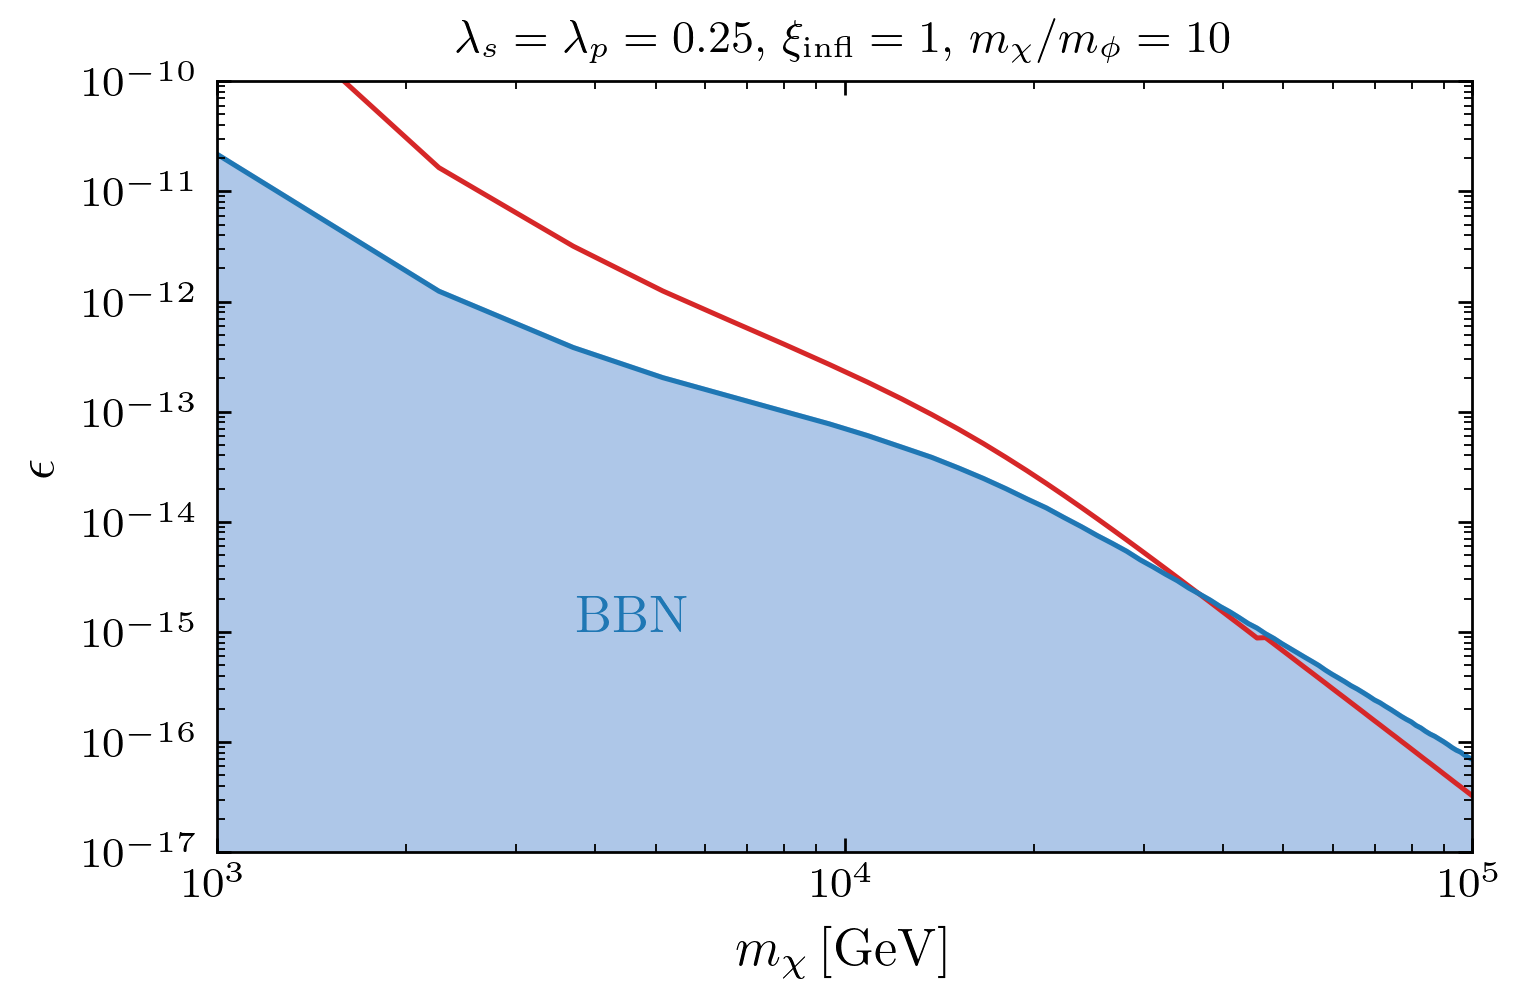

In [52]:
cs=plt.cm.tab20([0,1,2,3,4,5,6,7,8])
plt.plot(mXs1,epsXs1,lw=1,c=cs[6])
plt.fill_between(mXs_bbn,0, bbn_bound(mXs_bbn),lw=1,color=cs[1],alpha=1)
plt.plot(mXs_bbn,bbn_bound(mXs_bbn),lw=1,color=cs[0],ls='-')
plt.legend()
plt.yscale("log")
plt.xscale("log")
plt.ylabel("$\epsilon$")
plt.ylim(1e-17,1e-10)
plt.title(r'$\lambda_s=\lambda_p=0.25,\,\xi_{\rm infl}=1,\,m_\chi/m_{\phi}=10$',fontsize=9)
plt.xlim(1e3,1e5)
plt.text(dat1['mXstar']*5,1e-15,r"BBN",color=cs[0])
plt.xlabel(r"$m_\chi\,[{\rm GeV}]$")
plt.savefig("../figs/hP_lam2.5e-1_xiInf1_r10.png")
plt.savefig("../figs/hP_lam2.5e-1_xiInf1_r10.pdf")
plt.show()
plt.close()